In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LassoCV
from sklearn . ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

path = "dados_limpos.csv"

<h3><B>Analisando os Dados 
<h6>Há dados com uma grande variação, prejudicando a análise pela StandardScaler, dados como Age e Smokes (years), serão beneficiados pelo RobustScaler onde ignora os desvios padrões

In [ ]:
df_tratado = pd.read_csv(path)
colunas = ["Age","Number of sexual partners","First sexual intercourse","Citology",
           "Num of pregnancies","Smokes (years)","STDs","Hormonal Contraceptives (years)","Schiller","Biopsy"]

def checar_dados(coluna,nome):
    
    #Média Aritimética
    media = coluna.mean().round(2)
    #Variação da População
    var = coluna.var(ddof = 0).round(2)
    #Desvio Padrão
    std = coluna.std(ddof = 0).round(2)

    print("-----------")
    print(nome)
    print(f"Média: {media}\nVariancia: {var}\nStd: {std}")
    
for coluna in colunas:
    checar_dados(df_tratado[coluna],coluna)


-----------
Age
Média: 27.43
Variancia: 74.33
Std: 8.62
-----------
Number of sexual partners
Média: 2.54
Variancia: 2.8
Std: 1.67
-----------
First sexual intercourse
Média: 17.12
Variancia: 8.02
Std: 2.83
-----------
Citology
Média: 0.06
Variancia: 0.05
Std: 0.23
-----------
Num of pregnancies
Média: 2.33
Variancia: 2.04
Std: 1.43
-----------
Smokes (years)
Média: 1.23
Variancia: 17.16
Std: 4.14
-----------
STDs
Média: 0.11
Variancia: 0.1
Std: 0.31
-----------
Hormonal Contraceptives (years)
Média: 2.27
Variancia: 14.2
Std: 3.77
-----------
Schiller
Média: 0.1
Variancia: 0.09
Std: 0.3
-----------
Biopsy
Média: 0.07
Variancia: 0.07
Std: 0.26


<h3><b>Correlação e Relacionamento 
<h6>Notamos uma Forte relação de biópsia, com exames clínicos para testar o câncer como papanicolau, mas isso já era esperado, esses dados podem acabar viciando a IA em verifica-los, o problema é que seria mais interessante remove-los e abaixar a precisão da IA, em prool da utilidade e tentar identificar possíveis usuários com câncer antes deles fazerem exames.

<function matplotlib.pyplot.show(close=None, block=None)>

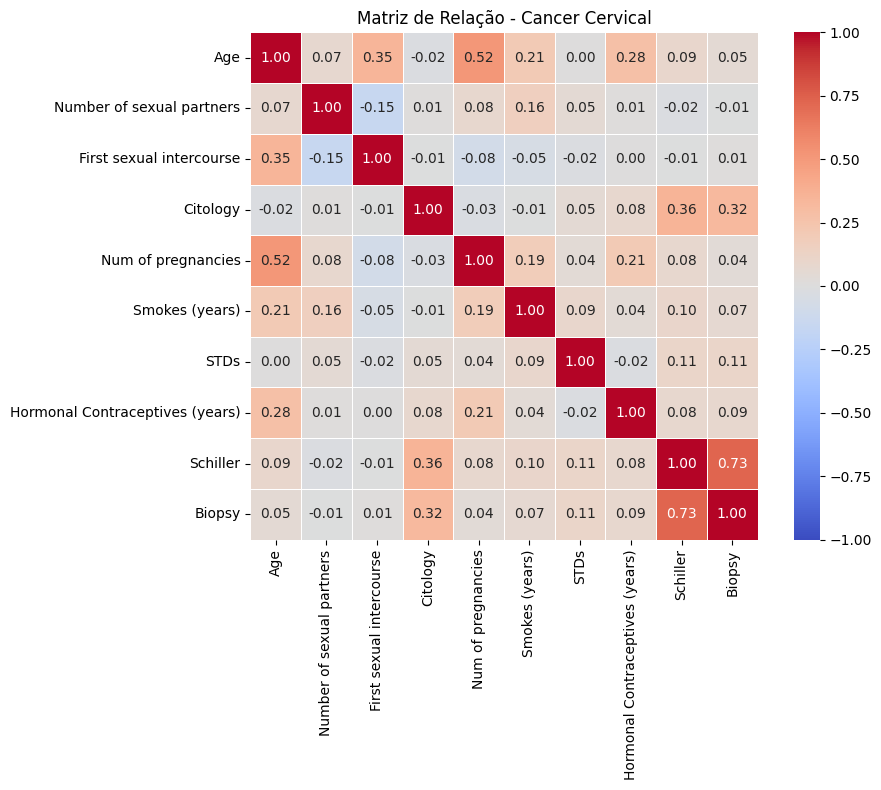

In [ ]:
corr_matrix = df_tratado[colunas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,         
    fmt='.2f',           
    cmap='coolwarm',     
    vmin=-1, vmax=1,     
    linewidths=0.5, 
    square=True
)

plt.title("Matriz de Relação - Cancer Cervical")
plt.tight_layout()
plt.show


<h3><b>Featuring Engenering Preparação de Dados</h3>
<h4>Precisamos utilizar técnicas de preparação de dados para melhor análise do nosso modelo, os valores da tabela podem ocorrer de ter grandes diferenças entre si, por exemplo, Age e Smokes(years), podem ter valores muito diferentes, e o modelo pode atribuir um peso maior a Age apenas pelos números serem maiores. Colocar as Variáveis na mesma escala evita esse comportamento e transforma os dados na mesma grandeza</h4>
<h4><b>RobustScaler</b>Utiliza a Mediana e Quartis(Divisão dos dados em 25%, RobustScaler utiliza especificamente os dados entre Q1-Q3, ou seja 25%-75% da maioria dos pacientes), não sendo afetados por valores fora do padrão, centralizando os dados na maioria dos casos</h4>


$$ 
x' = \frac{x - \text{mediana}(X)}{Q_3(X) - Q_1(X)} 
\\
\text{\small Algoritmo de Escalonamento Robusto (RobustScaler)}
$$


<h4><b>Motivo da Escolha do RobustScaler:</b> O StandardScaler utiliza a média, e o MinMax utiliza os menores e maiores valores, tendo que eliminar os outliers para utilizar nos dois casos, por eu interpretar os Outliers não como erro de coleta de dados, mas apenas como indíviduos que se destacam, preferindo mante-los, achei melhor utilizar o RobustScaler, assim tanto o StandScaler quanto o MinMax focariam muito mais que o necessário nos valores Outline influenciando no modelo</h4>

In [ ]:
def scalat_data(df):
    scaler = RobustScaler()
    df_escalado = pd.DataFrame(
        scaler.fit_transform(df),
        columns=df.columns
    )
    return df_escalado

df_escalado = scalat_data(df_tratado)

print(df_escalado.head(6))

        Age  Number of sexual partners  First sexual intercourse  \
0 -0.666667                        2.0                 -0.666667   
1 -0.916667                       -1.0                 -1.000000   
2  0.666667                       -1.0                  0.000000   
3  2.166667                        3.0                 -0.333333   
4  1.666667                        1.0                  1.333333   
5  1.333333                        1.0                  2.000000   

   Num of pregnancies  Smokes  Smokes (years)  Smokes (packs/year)  \
0                -0.5     0.0             0.0                  0.0   
1                -0.5     0.0             0.0                  0.0   
2                -0.5     0.0             0.0                  0.0   
3                 1.0     1.0            37.0                 37.0   
4                 1.0     0.0             0.0                  0.0   
5                 0.0     0.0             0.0                  0.0   

   Hormonal Contraceptives  Horm

<h3><b>Feacture Selection

<h5>Olhando e Analisando os Dados Diretamente

In [ ]:
#Descartei os dados SCHILLER e Citology para não viciar minha IA
#Numbers of Parcey foi descartado devido a total não relação entre a biópsia e ele
dados_importantes = [
    'Age', 'First sexual intercourse', 'Num of pregnancies', 
    'Smokes (years)', 'Hormonal Contraceptives (years)','STDs'
]

#Selecionando somente as colunas desejadas
df_colunas_selecionadas = df_escalado[dados_importantes]
print(df_colunas_selecionadas)

          Age  First sexual intercourse  Num of pregnancies  Smokes (years)  \
0   -0.666667                 -0.666667                -0.5             0.0   
1   -0.916667                 -1.000000                -0.5             0.0   
2    0.666667                  0.000000                -0.5             0.0   
3    2.166667                 -0.333333                 1.0            37.0   
4    1.666667                  1.333333                 1.0             0.0   
..        ...                       ...                 ...             ...   
736  0.666667                  0.333333                -1.0             0.0   
737  0.500000                  0.666667                -0.5             0.0   
738 -0.083333                  0.000000                -1.0             0.0   
739  0.583333                  2.333333                 0.0             0.0   
740  0.250000                  1.000000                -0.5             0.0   

     Hormonal Contraceptives (years)  STDs  
0     

<h1><b>Lasso</b></h1>
<h4>Adiciona uma multa (penalidade) nos valores aplicados, ele adiciona um valor para W, se ele for pequeno, indica pouca relação com a coluna selecionada ("Biopsy" no caso), entretanto, ele quer que o somatório de toda a coluna W, seja o menor possivel, então preferencialmente ele tenta abaixar esses valores e deixar mais próximo de zero, valores próximos de zero são descartados e considerados não relacionados.</h4>
<h4>A necessidade de um W próximo de zero, é para otimização do modelo para não tentar se ajustar a cada detalhe, assim podendo criar algo mais reduto e com menos overfitting</h4>

$$
\text{Loss}_{\text{Lasso}} = \underbrace{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}_{\text{prediction error}} + \lambda \underbrace{\sum_{j=1}^{d} |\beta_j|}_{\text{L1 penalty}}
\\
\text{\small Algoritmo Matemático em que o Lasso baseia-se}
$$

In [ ]:
#Utiliza o Lasso para definir quais pesos (W) serão mantidos ou não

X = df_tratado.drop(columns=['Biopsy']) #Banco de dados sem a Biopsy
y = df_tratado['Biopsy'] # alvo que o modelo tenta prever, precisa remover o Biopsy para não se criar um algorítimo viciado, Bipsy sempre terá um relacionamento de 100% consigo mesmo, e zeraria o resto

#Cv é a quantidade de tabelas feitas parece treinar o Lasso, entretanto aumenta o tempo de processamento (cv=5 ~0.1 segundos,cv=10 ~0.1 segundos,cv=20 ~0.2 segundos) Projetos reais podem se preocupar mais com isso
#Cv é uma validação cruzada, divide os dados 5 vezes, testa eles, e valida no quinto dado
lasso = LassoCV(cv=5, random_state=42)

#Recebe os dados reais e testa o valor de peso em cada coluna
lasso.fit(X, y) 

#Organiza os dados
coef_df = pd.Series(np.abs(lasso.coef_), index=X.columns)

print(coef_df.sort_values(ascending=False).head(6))

#Apenas para pegar as colunas que não foram zeradas
selecionados_lasso = coef_df[coef_df!= 0].index.tolist()

print(selecionados_lasso)

Schiller      0.539814
Hinselmann    0.123102
Dx:CIN        0.073476
Dx            0.046190
Citology      0.045835
STDs          0.009316
dtype: float64
['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs', 'Dx:CIN', 'Dx', 'Hinselmann', 'Schiller', 'Citology']


<h3><b>Normalizandos os dados do Lasso</b></h3>

In [ ]:
scaler = MinMaxScaler()

lasso_valores_2d = coef_df.values.reshape(-1, 1)
lasso_norm_values = scaler.fit_transform(lasso_valores_2d)

lasso_df_norm = pd.Series(lasso_norm_values.flatten(), index=coef_df.index).sort_values(ascending=False)

print(lasso_df_norm.head(6))

Schiller      1.000000
Hinselmann    0.228045
Dx:CIN        0.136114
Dx            0.085567
Citology      0.084909
STDs          0.017258
dtype: float64


In [ ]:
def lasso_feacture(X,y):
    lasso = LassoCV(cv=5, random_state=42)

    lasso.fit(X, y) 

    coef_df = pd.Series(np.abs(lasso.coef_), index=X.columns)

    scaler = MinMaxScaler()

    lasso_valores_2d = coef_df.values.reshape(-1, 1)
    lasso_norm_values = scaler.fit_transform(lasso_valores_2d)

    lasso_df_norm = pd.Series(lasso_norm_values.flatten(), index=coef_df.index).sort_values(ascending=False)

    return lasso_df_norm


<h3><b>Floresta Aleatória</b></h3>
<h4>Baseia a decisão, na média dos dados coletados e analisados pelas árvores geradas aleatoriamente, evita o overlifiting, e cria um ambiente como uma espécie de "democracia" da maioria, menos minimalista que o lasso e também, considera os valores bem baixos, como por exemplo "STDs" que ficou com uma pontuação baixa na tabela.</h4>

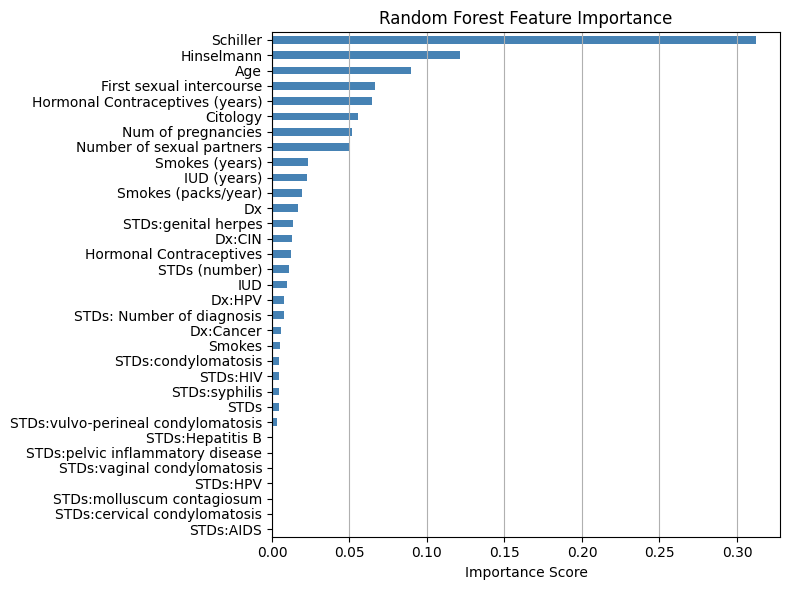

Schiller                           0.312132
Hinselmann                         0.121384
Age                                0.089446
First sexual intercourse           0.066239
Hormonal Contraceptives (years)    0.064825
Citology                           0.055506
dtype: float64


In [ ]:
#Quantidade de Árvores de decisão, quanto mais árvores melhor o veredito, entretanto mais pesada, random_state = seed
#Se uma árvore ocorrer o overliffintg, terá problema, ainda terá 99 árvores para fazer a média dos resultados
rf = RandomForestClassifier (n_estimators =100,random_state=42)

#Lendo os Dados, utilizando o X=Lista e comparando com y a coluna que me interessa
rf.fit(X,y)

#feature_importances_, pega os valores mais importantes e organiza com base nas colunas usadas.
mais_importantes = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure(figsize=(8, 6))
mais_importantes.sort_values(ascending=True).plot(kind='barh', color='steelblue')
plt.grid(axis='x', linestyle='-', alpha=1)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()



#Principais valores 
print(mais_importantes.sort_values(ascending=False).head(6))

<h3><b>Normalizandos os dados do Randon Forest</b></h3>

In [ ]:
scaler = MinMaxScaler()

rf_valores_2d = mais_importantes.values.reshape(-1, 1)
rf_norm_values = scaler.fit_transform(rf_valores_2d)

rf_df_norm = pd.Series(rf_norm_values.flatten(),index=mais_importantes.index).sort_values(ascending=False)

print(rf_df_norm.head(9))

Schiller                           1.000000
Hinselmann                         0.388888
Age                                0.286564
First sexual intercourse           0.212216
Hormonal Contraceptives (years)    0.207685
Citology                           0.177830
Num of pregnancies                 0.164787
Number of sexual partners          0.160897
Smokes (years)                     0.074019
dtype: float64


In [ ]:
def random_forest(X,y):
    rf = RandomForestClassifier (n_estimators =100,random_state=42)

    rf.fit(X,y)

    mais_importantes = pd.Series(rf.feature_importances_, index=X.columns)

    scaler = MinMaxScaler()

    rf_valores_2d = mais_importantes.values.reshape(-1, 1)
    rf_norm_values = scaler.fit_transform(rf_valores_2d)

    rf_df_norm = pd.Series(rf_norm_values.flatten(),index=mais_importantes.index).sort_values(ascending=False)

    return rf_df_norm


<h4><b>Mutual Information</b></h4>

<h3>Mensura quanto uma informção tem conhecimento sobre a outra, calculando a dependência de uma variável em relação a outra, por exemplo, se o valor de X e Y forem TOTALMENTE independentes, o valor de X não ajuda a entender nada o valor de Y, quanto mais o valor de X tem relação com o valor de Y, mas alto será seu valor de MI.</h3>

$$ 
I(X;Y) = \sum_{x,y} P(x,y) \log \frac{P(x,y)}{P(x)P(y)} 
\\
\text{\small Feature Selection Algorithm (Mutual Information)}
$$

In [ ]:
mi_scores = mutual_info_classif(X,y,random_state=42)
mi_df = pd.Series(mi_scores,index=X.columns).sort_values(ascending=False)
print(mi_df.head(6))

Schiller                      0.155837
Hinselmann                    0.070420
Age                           0.027741
Citology                      0.025981
Smokes (years)                0.024277
STDs:molluscum contagiosum    0.018309
dtype: float64


<h3><b>Normalizando os Dados do MI</b></h3>

In [ ]:
scaler = MinMaxScaler()
mi_valores = mi_df.values.reshape(-1,1)
mi_normalizado = scaler.fit_transform(mi_valores)

mi_df_norm = pd.Series(mi_normalizado.flatten(),index=mi_df.index).sort_values(ascending=False)

print(mi_df_norm.head(6))

Schiller                      1.000000
Hinselmann                    0.451885
Age                           0.178010
Citology                      0.166719
Smokes (years)                0.155784
STDs:molluscum contagiosum    0.117491
dtype: float64


In [ ]:
def mi_feacture_select(X,y):
    mi_scores = mutual_info_classif(X,y,random_state=42)
    mi_df = pd.Series(mi_scores,index=X.columns).sort_values(ascending=False)
    scaler = MinMaxScaler()
    mi_valores = mi_df.values.reshape(-1,1)
    mi_normalizado = scaler.fit_transform(mi_valores)

    mi_df_norm = pd.Series(mi_normalizado.flatten(),index=mi_df.index).sort_values(ascending=False)

    return mi_df_norm

<h3>VIF</h3>

In [ ]:
def vif_cleaning(X):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = X.columns
    vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    #print(vif_df.sort_values(by="VIF",ascending=False))

    colunas_excluir = []

    for nome, row in vif_df.iterrows():
            if row["VIF"]>=10:
                colunas_excluir.append(row["Feature"])

    X_final = X.drop(columns=colunas_excluir,errors='ignore')

    return X_final

X_final = vif_cleaning(df_tratado)

print(X_final.head(10))


   Number of sexual partners  Num of pregnancies  Smokes  Smokes (years)  \
0                        4.0                 1.0     0.0        0.000000   
1                        1.0                 1.0     0.0        0.000000   
2                        1.0                 1.0     0.0        0.000000   
3                        5.0                 4.0     1.0       37.000000   
4                        3.0                 4.0     0.0        0.000000   
5                        3.0                 2.0     0.0        0.000000   
6                        3.0                 6.0     1.0       34.000000   
7                        1.0                 3.0     0.0        0.000000   
8                        1.0                 5.0     0.0        0.000000   
9                        3.0                 2.0     1.0        1.266973   

   Smokes (packs/year)  Hormonal Contraceptives  \
0                  0.0                      0.0   
1                  0.0                      0.0   
2         

c:\Users\Gabri\OneDrive\Desktop\Projeto Kaggle IA\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\Gabri\OneDrive\Desktop\Projeto Kaggle IA\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


<h3><b>Selecionando as top feactures</b></h3>

In [ ]:
def select_top_features(X, y, n_top=10):
    X = top_feactures(X)
    rf_scores = random_forest(X, y)       
    mi_scores = mi_feacture_select(X, y)    
    lasso_scores = lasso_feacture(X, y)     
    
    tabela = pd.DataFrame({
        'RF': rf_scores,
        'MI': mi_scores,
        'Lasso': lasso_scores
    })
    
    tabela['Media'] = tabela.mean(axis=1)
    
    tabela = tabela.sort_values('Media', ascending=False)
    
    top_features = tabela.head(n_top).index.tolist()
    
    return top_features

top_feactures = select_top_features(X_final,y)
print(top_feactures)


['Biopsy', 'Schiller', 'Hinselmann', 'Citology', 'IUD', 'Num of pregnancies', 'Hormonal Contraceptives (years)', 'IUD (years)', 'Smokes (packs/year)', 'Dx:HPV']
